# TV sweep: Burgers (noise=0.7, stride_x=5)

Baseline matches `noise_test.ipynb` cell 46: `noise=0.7`, `stride_x=5`.

This notebook sweeps `lambda_tv` while training `(u_model=SimpleMLP, v_model=EQL)` and records:
- final losses
- `symnet.readout.weight` and effective quadratic matrix
- a coefficient proxy for the `u*u_x` term via `M_sym[u,ux] + M_sym[ux,u]`
- derivative sanity check `||ux_fd - ux_autograd||_inf` on one time slice

TV here is implemented as a smoothed spatial TV penalty: `E[ sqrt( (?u/?x)^2 + eps^2 ) ]` (Charbonnier smoothing).


In [48]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from prog import mlps, featlib, trainer,hlprs
import Datasets.matconv as mc
from matplotlib import animation

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [53]:
# Dataset + training settings (noise=0.7, stride_x=5 baseline)

noise = 0.7
nu = 0.02
stride_t = 10
stride_x = 10
part_num = 1
which_part = 1
seed = SEED

selected_derivs = ('u','u_x','u_xx')

lr = 1e-3
batch_size = 1000
steps = 8000
log_every = 1000

lam_pde = 0.5
lam_reg = 0.0
lam_data = 10.0

# Sweep these:
lambda_tv_values = [0.0, 1e-5, 1e-3, 1e-1, 1.0]

# Fix activation to isolate TV effect (change if you want):
ACT = mlps.Sin


In [54]:
# Build dataset

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=seed,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 676
x_unique: 26 t_unique: 26


In [55]:
# TV penalty (smoothed TV in space)

def tv1d_space(u_fn, t, x, eps=1e-6):
    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(ux**2 + eps**2)
    return tv.mean()


In [56]:
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64,act=mlps.Sin)
symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=1.0, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)

In [57]:
train_config.lambda_pde = 0.5
train_config.lambda_data = 10.0
train_config.lambda_tv = 1.0
for params in u_model.parameters(): 
    params.requires_grad = True
for params in symnet.parameters(): 
    params.requires_grad = True

PERFORMING SWEEP OF LAMBDA TV VALS
CURRENT LAMBDA TV VALUE:0.0
step 0 data_loss=0.9917309284210205 pde_loss=0.0007089038845151663
step 1000 data_loss=0.5331879258155823 pde_loss=0.017473693937063217
step 2000 data_loss=0.514711856842041 pde_loss=0.08681520819664001
step 3000 data_loss=0.46801644563674927 pde_loss=0.12147552520036697
max_abs_diff = 0.483518
PERFORMING SWEEP OF LAMBDA TV VALS
CURRENT LAMBDA TV VALUE:1e-05
step 0 data_loss=1.0936968326568604 pde_loss=0.005521136801689863
step 1000 data_loss=0.5064901113510132 pde_loss=0.02586623653769493
step 2000 data_loss=0.4988614320755005 pde_loss=0.02237117476761341
step 3000 data_loss=0.45540204644203186 pde_loss=0.04413647577166557
max_abs_diff = 0.601182
PERFORMING SWEEP OF LAMBDA TV VALS
CURRENT LAMBDA TV VALUE:0.001
step 0 data_loss=1.0307261943817139 pde_loss=0.0018776070792227983
step 1000 data_loss=0.5366683602333069 pde_loss=0.014906257390975952
step 2000 data_loss=0.5068030953407288 pde_loss=0.07157972455024719
step 3000 da

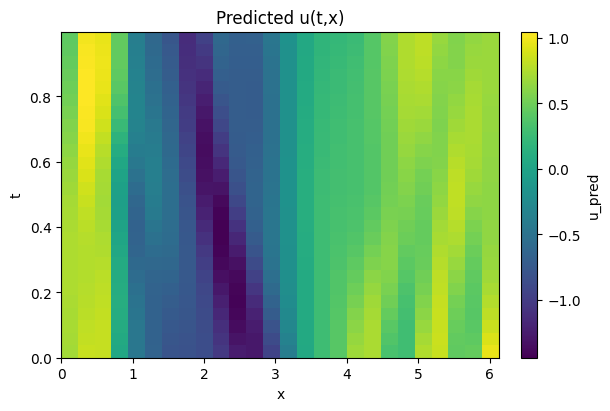

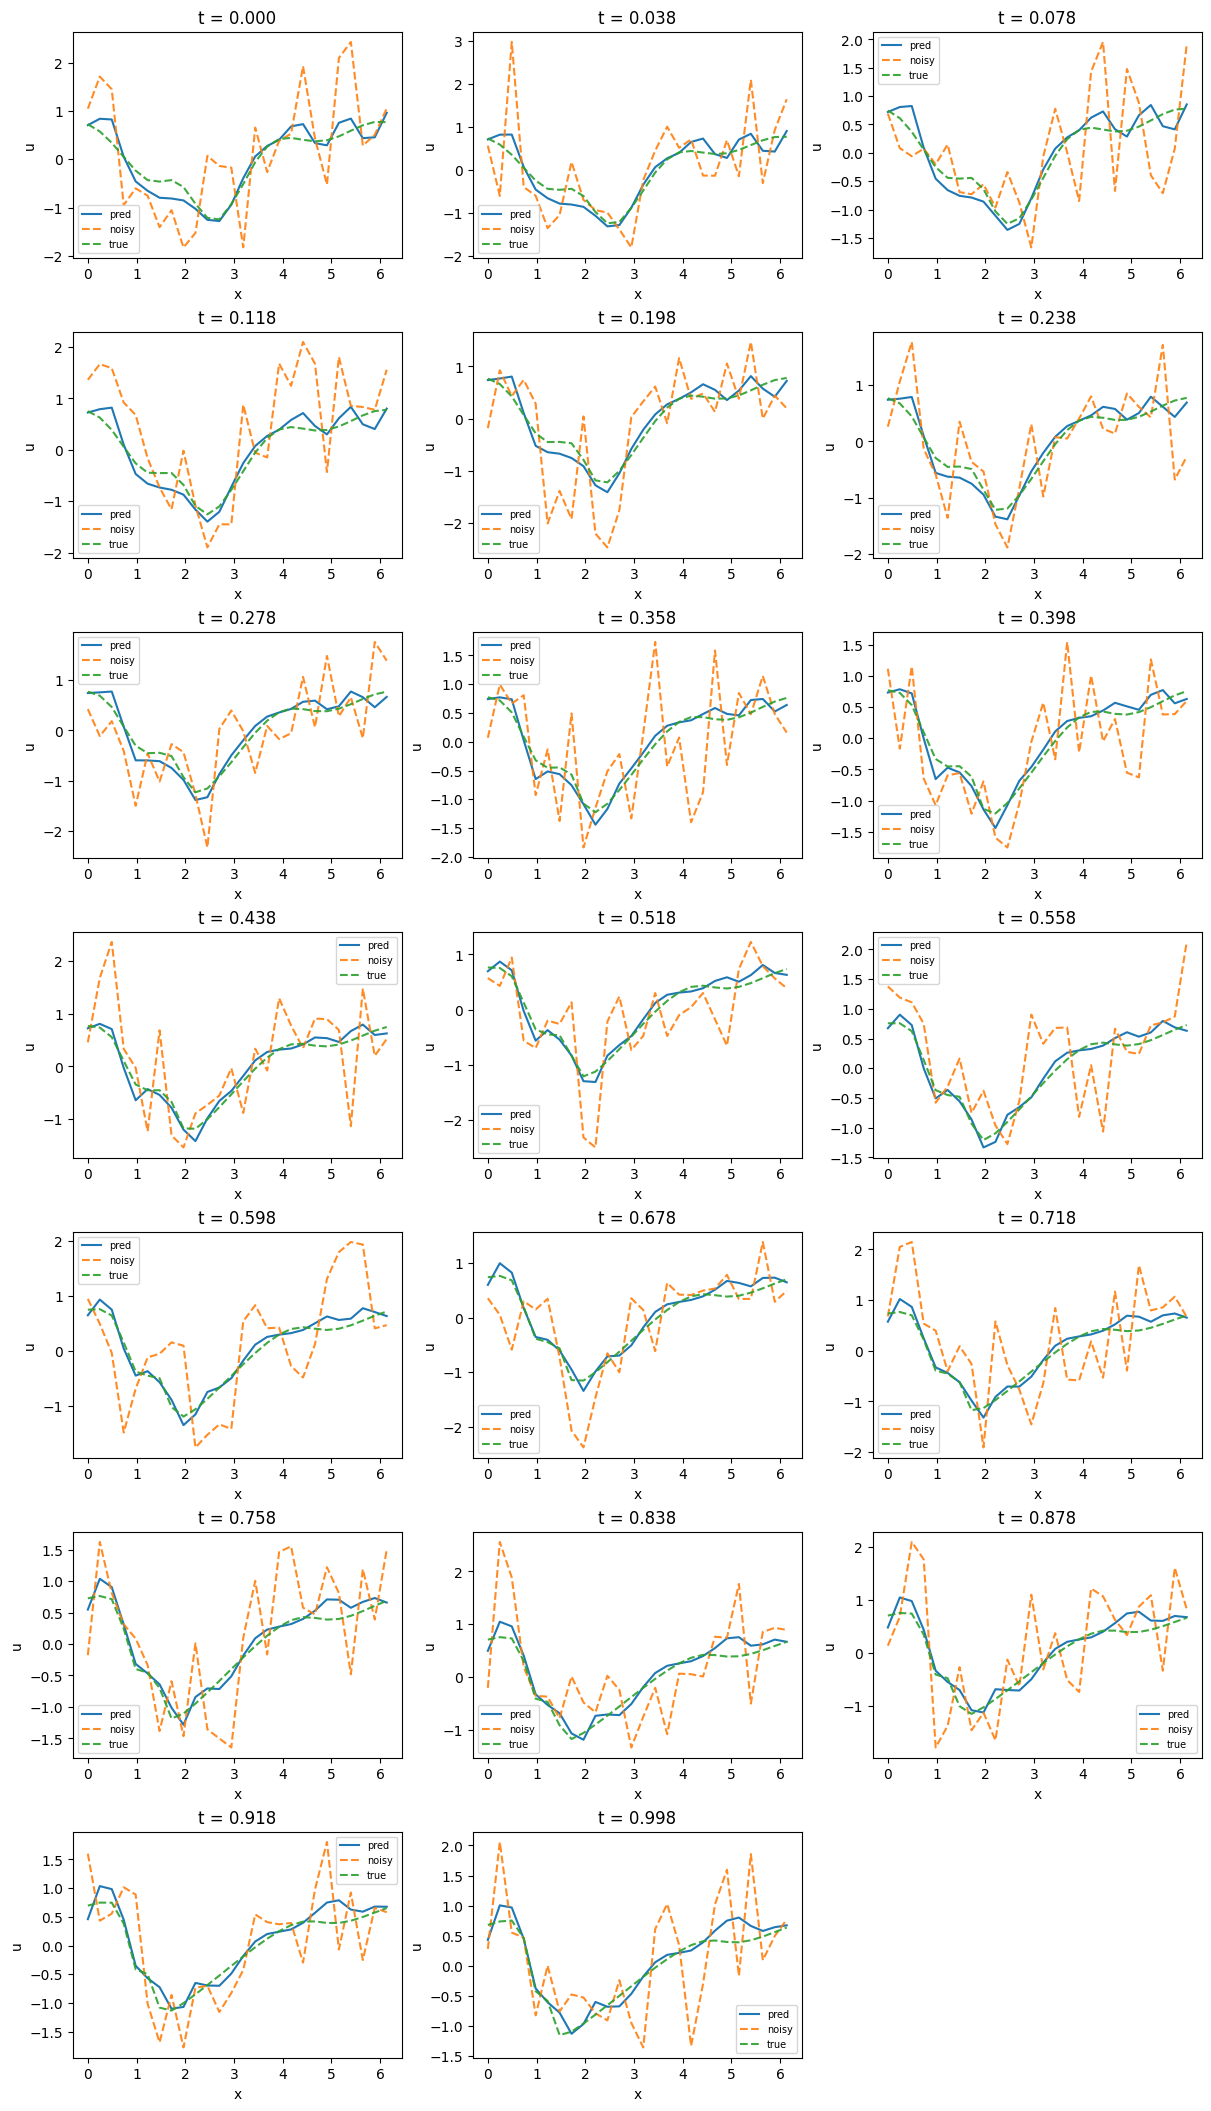

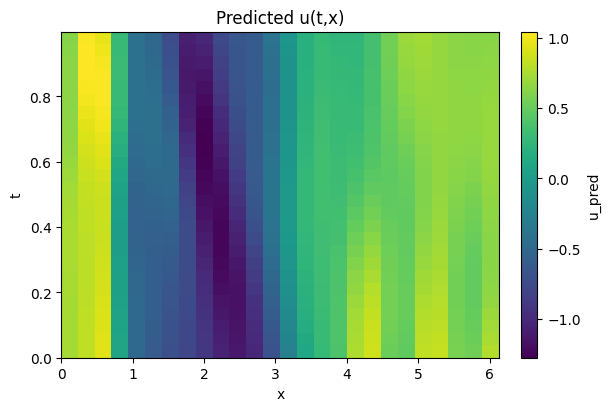

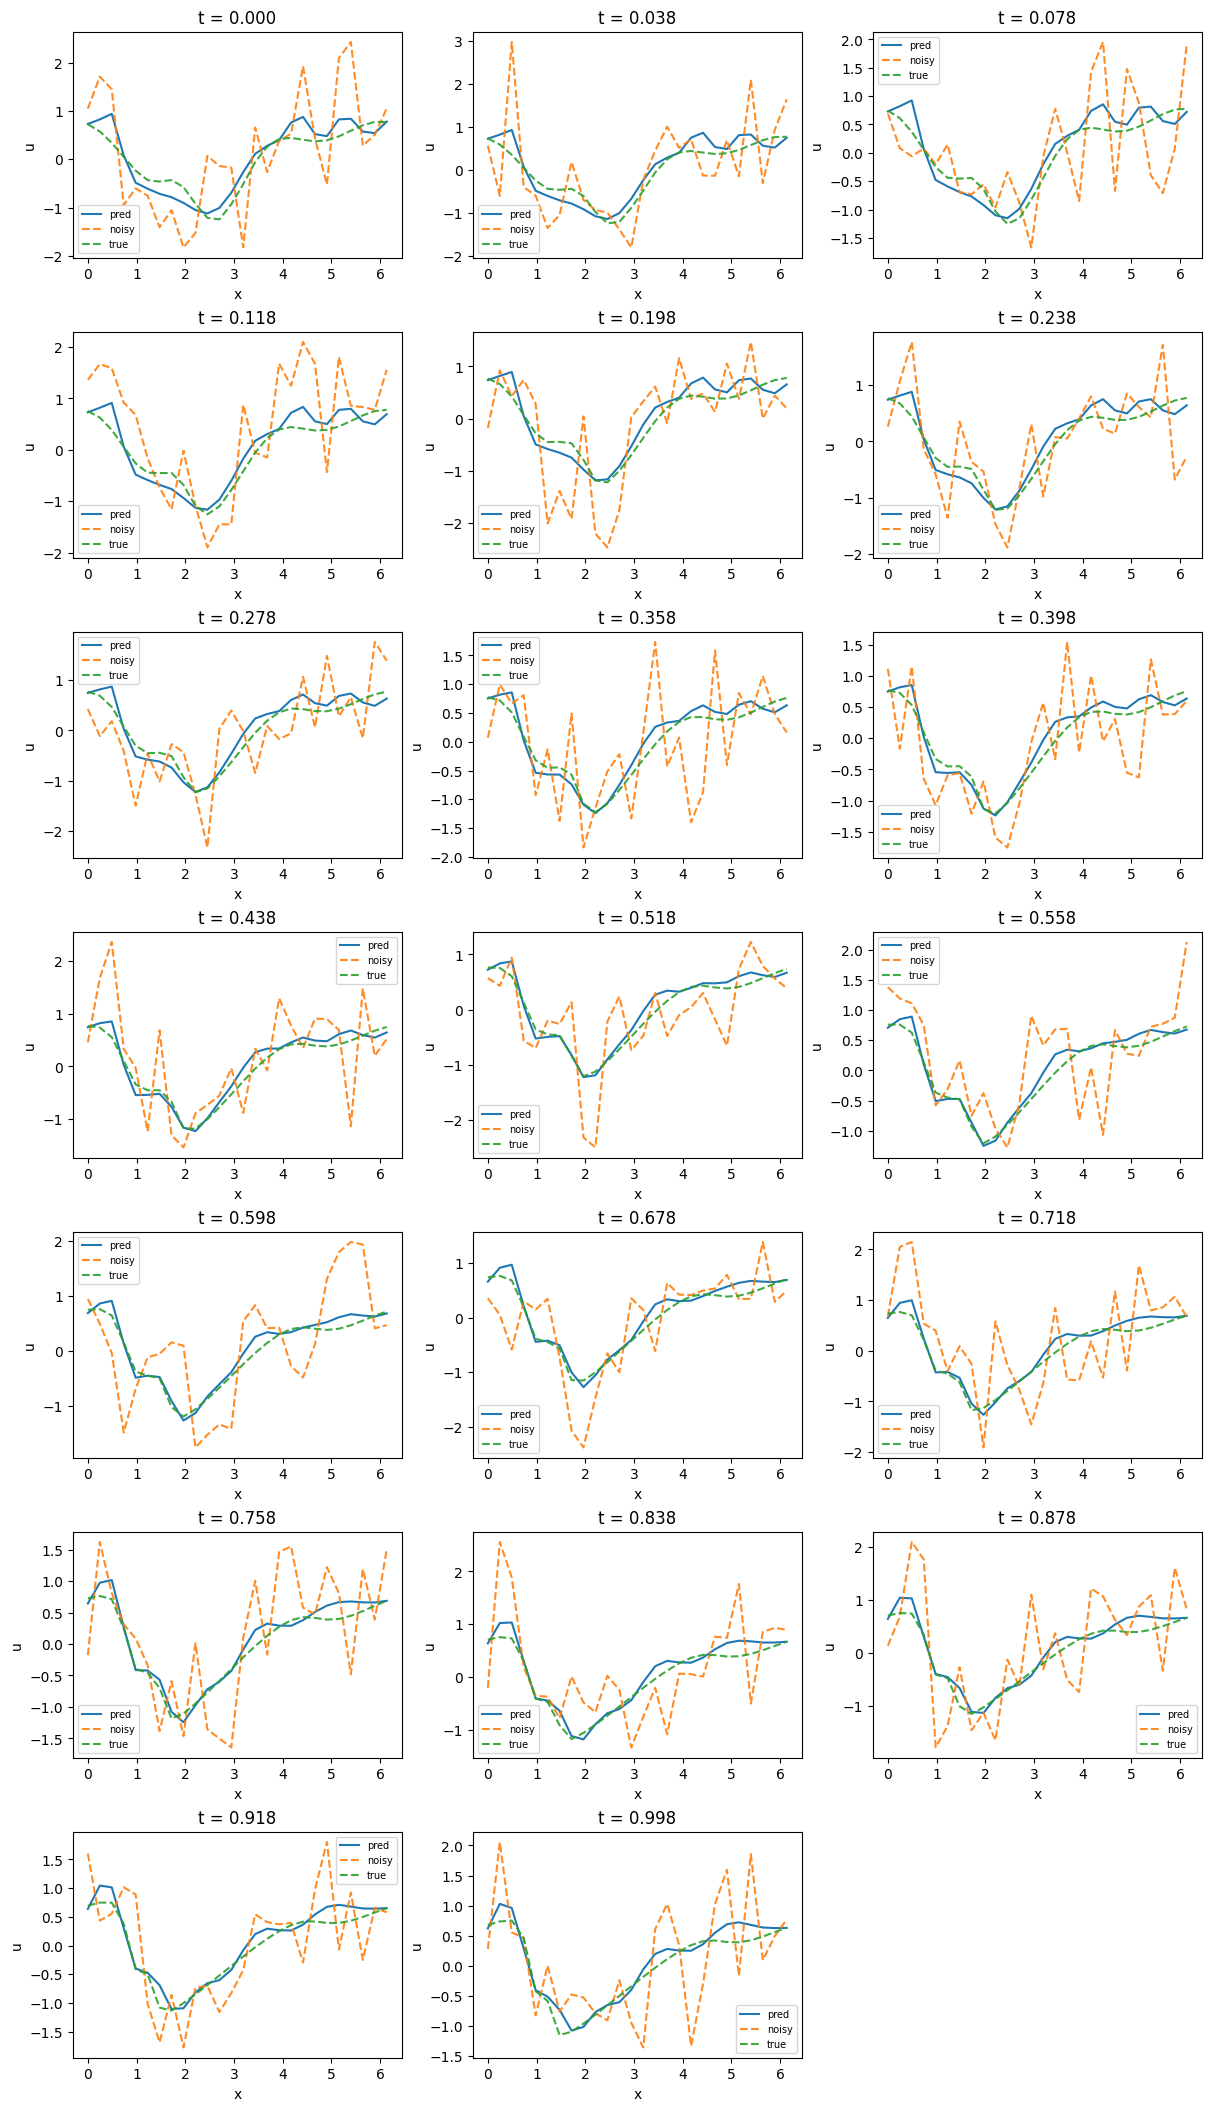

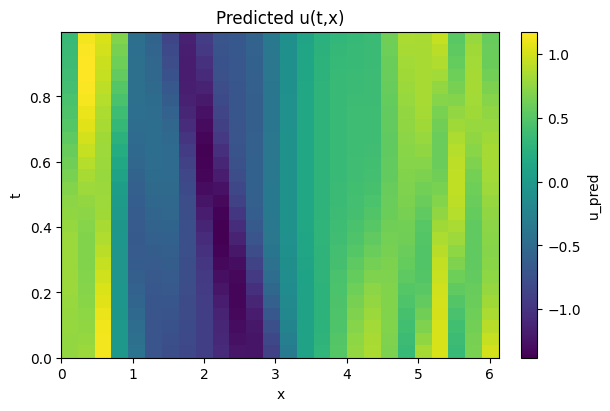

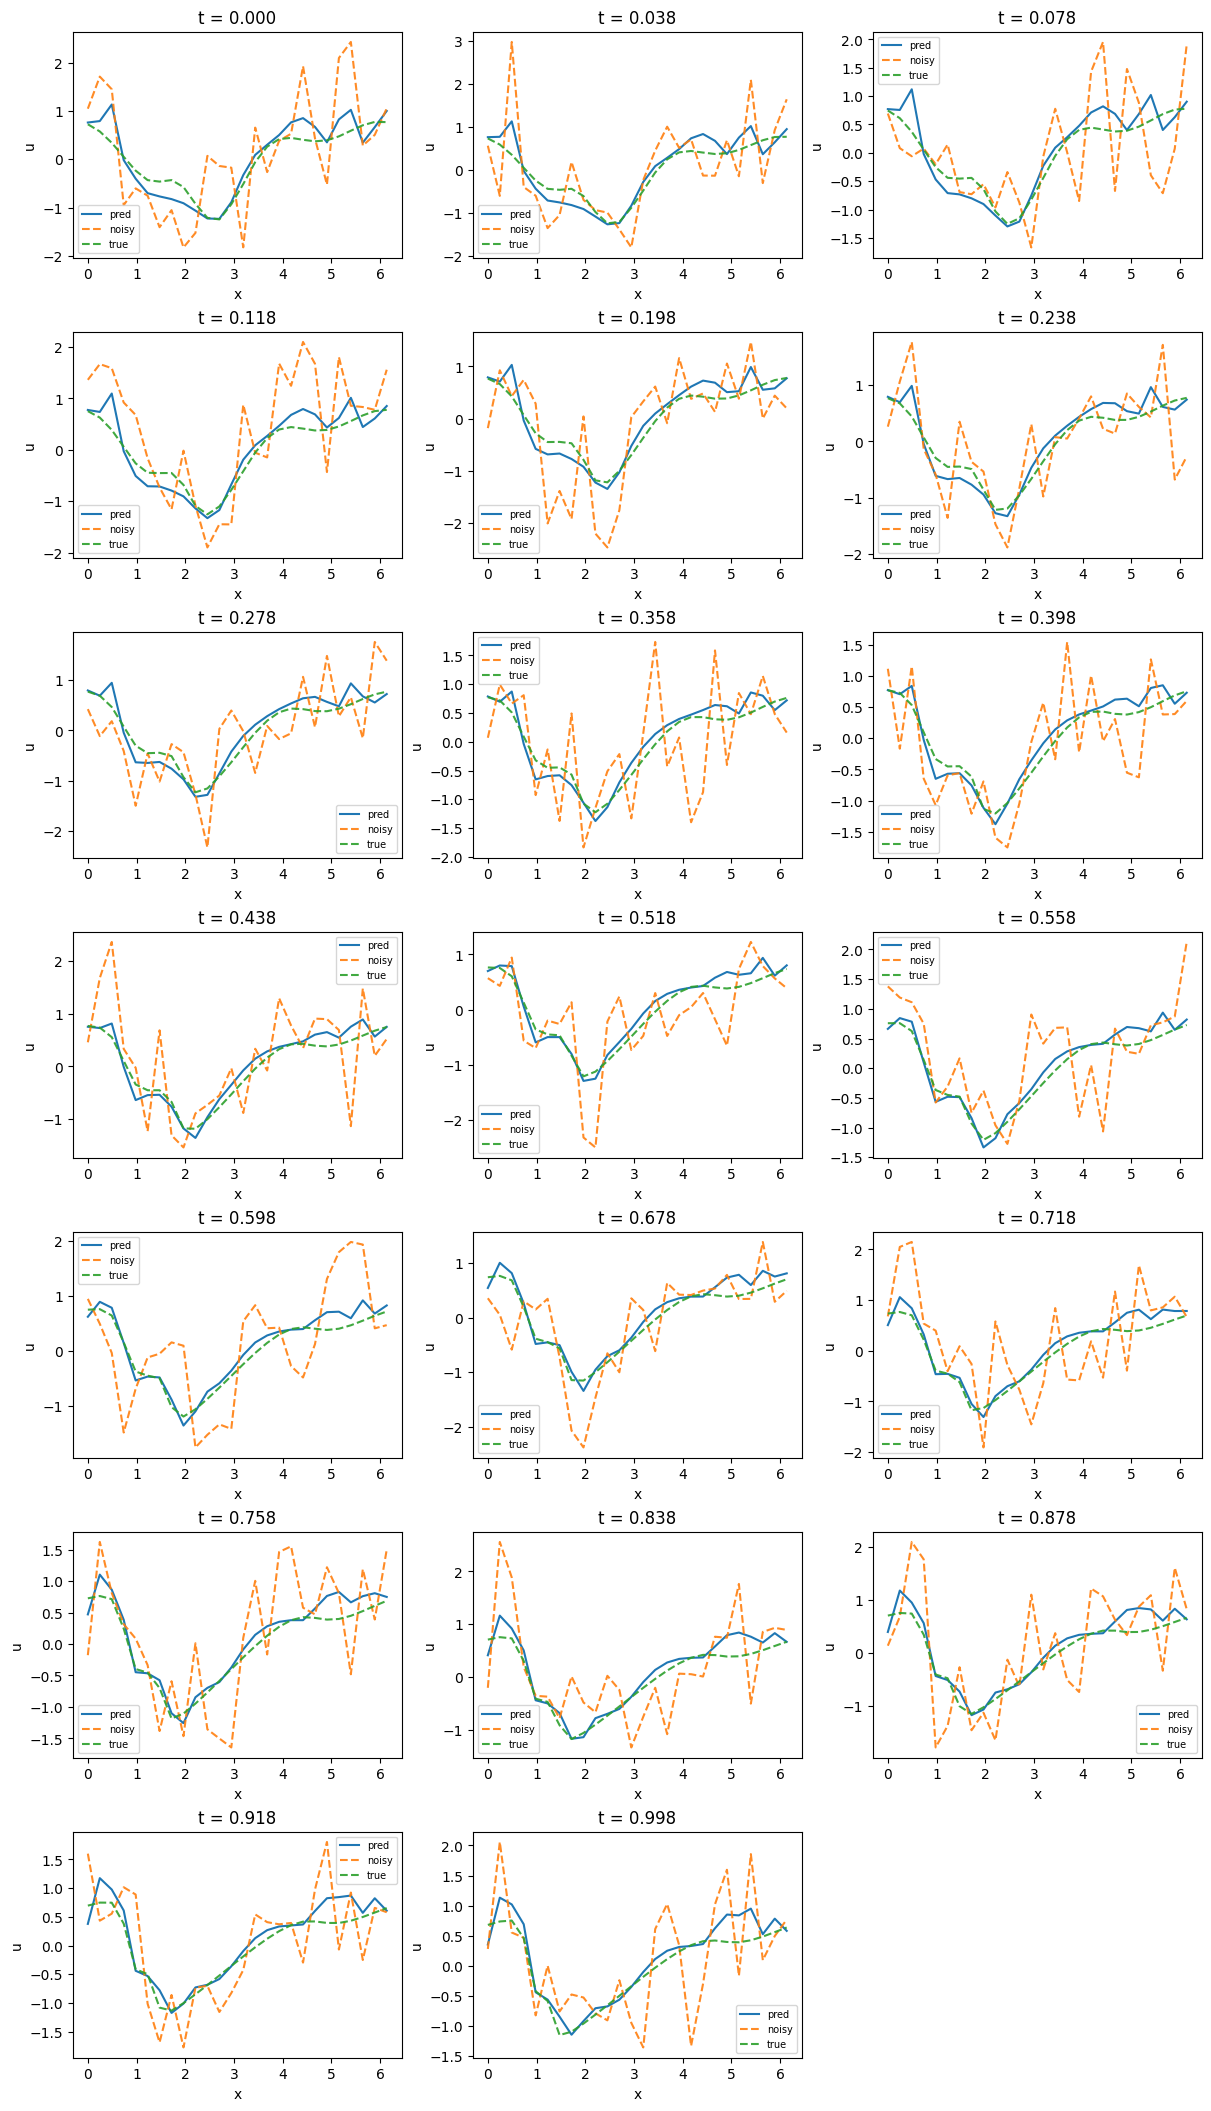

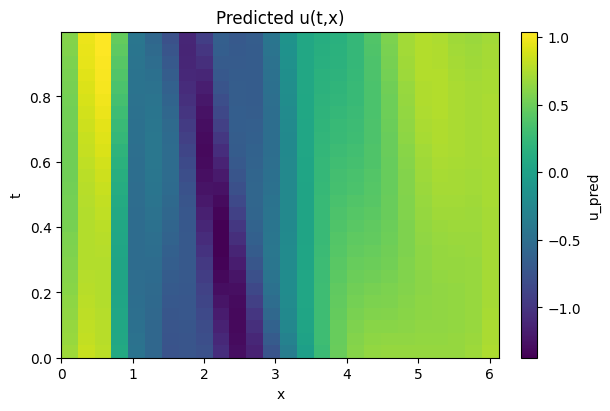

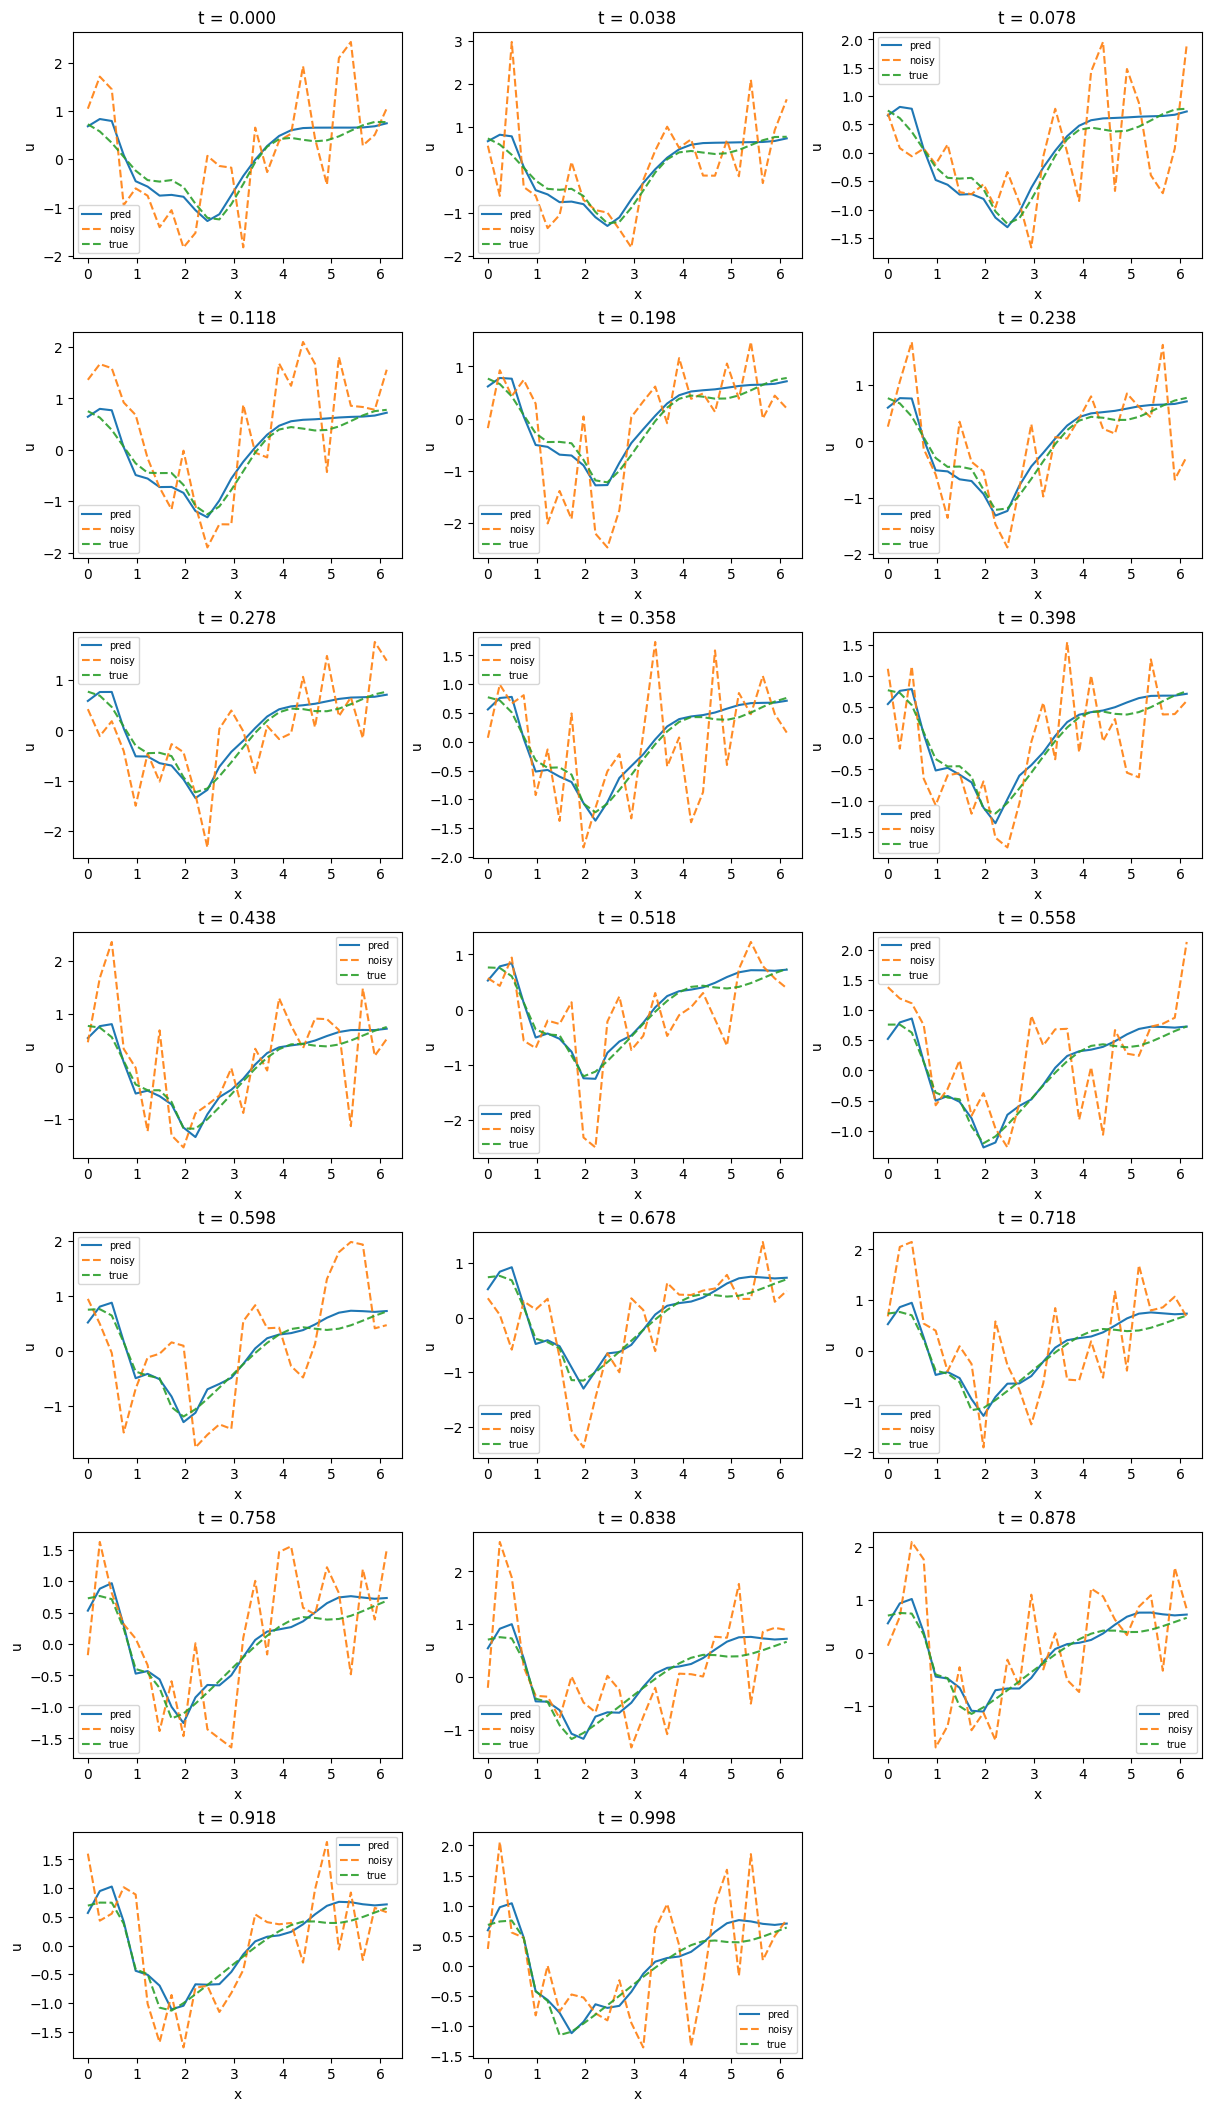

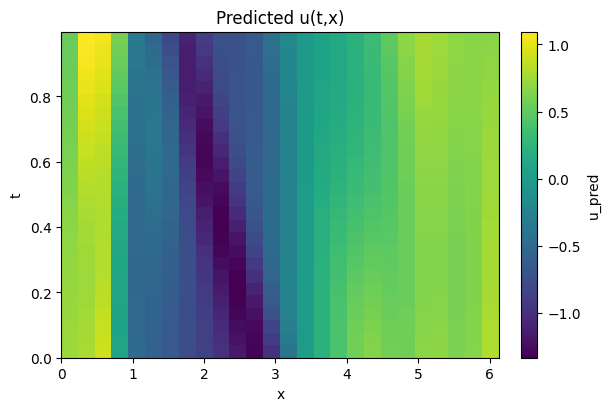

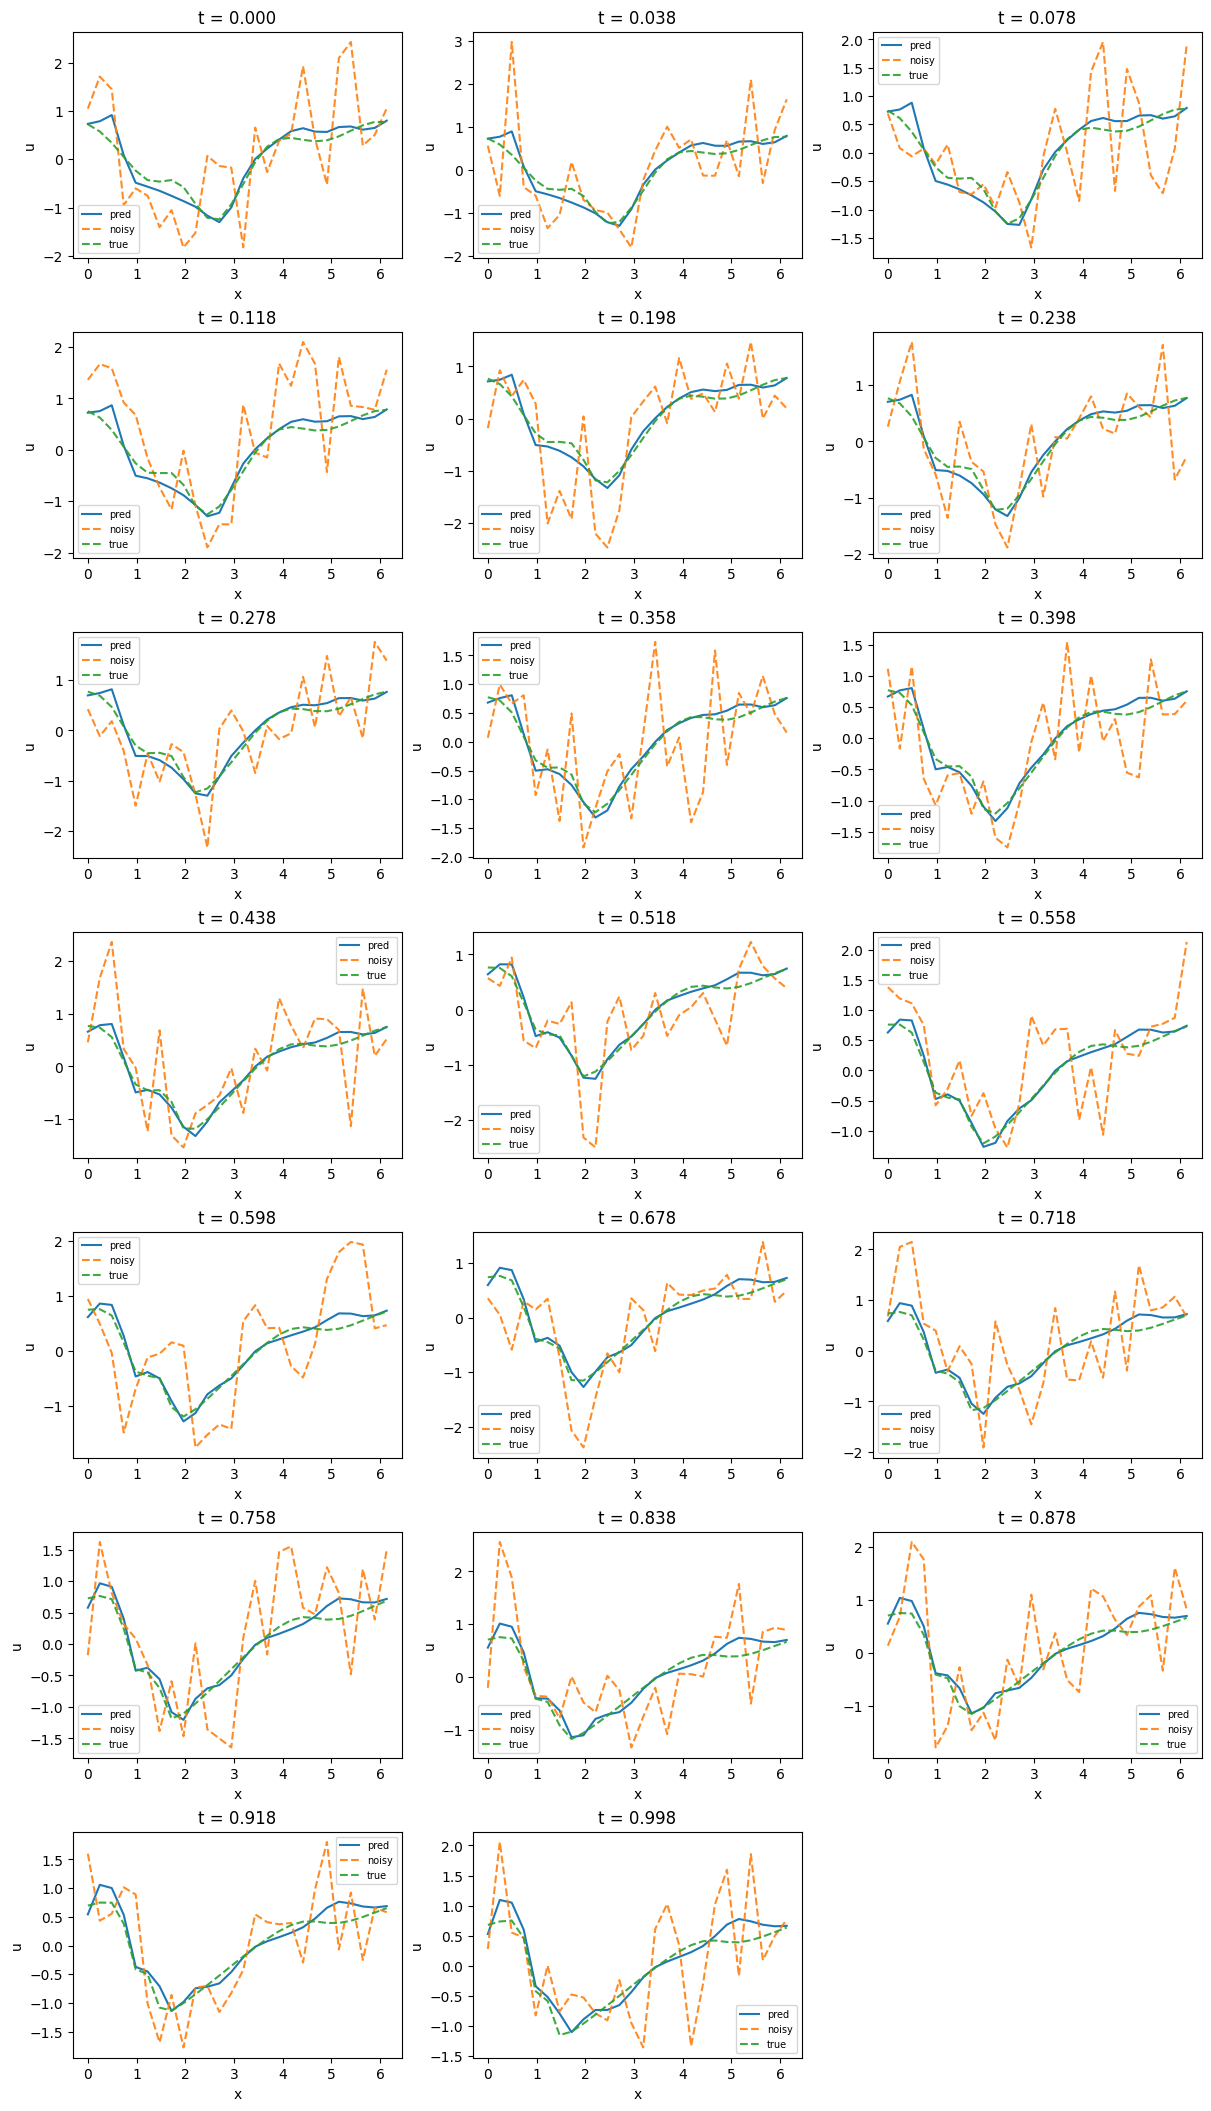

In [62]:
for lamtv in lambda_tv_values:
    u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64,act=mlps.Sin)
    symnet=mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, bias=False) # dummy v_model for working code
    train=trainer.PDETrainer(u_model=u_model,v_model=symnet,cfg=train_config, feature_builder=feature_builder)
    train_config.lambda_tv=lamtv

    print(f'PERFORMING SWEEP OF LAMBDA TV VALS')
    print(f'CURRENT LAMBDA TV VALUE:{lamtv}')
    for i in range(4000): 
        t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch, y_clean=y_clean_torch, y_noisy=y_noisy_torch)
        out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
        ld = out['loss_data']
        lp = out['loss_pde']
        if i%log_every==0:
            print(f'step {i} data_loss={ld} pde_loss={lp}')
    print(hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=20)[:0])


{'loss': 10.307592391967773, 'loss_data': 1.0305078029632568, 'loss_pde': 0.00502700125798583, 'l1': 3.133418083190918, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 4.986809253692627, 'loss_data': 0.49735984206199646, 'loss_pde': 0.02642151527106762, 'l1': 2.405468225479126, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 4.979875564575195, 'loss_data': 0.4967702627182007, 'loss_pde': 0.024345746263861656, 'l1': 3.042841672897339, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}
{'loss': 5.191587924957275, 'loss_data': 0.5169616937637329, 'loss_pde': 0.04394214600324631, 'l1': 3.087924003601074, 'loss_tv': 0.0, 'feature_names': ['u', 'u_x', 'u_xx'], 'feature_scales': tensor([1., 1., 1.])}


(-1.1061277389526367, 1.208595871925354)

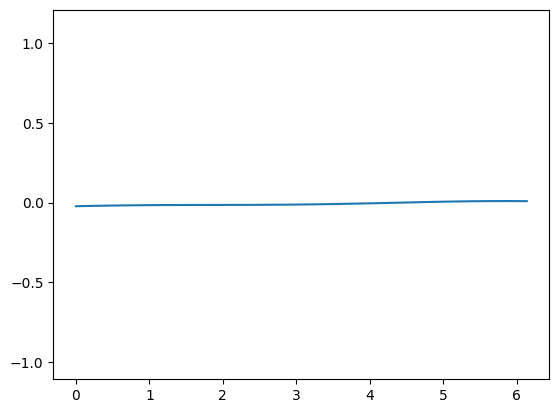

In [ ]:
snap_u = []
snap_meta = []
snap_step=10
read_step=1000

# fixed eval tensors
x_grid = np.unique(x_np)
x_eval = torch.tensor(x_grid, dtype=torch.float32, device=device).unsqueeze(1)
t_k = float(np.unique(t_np)[-2])  # or pick explicitly
t_eval = torch.full_like(x_eval, t_k)

for step in range(4000):
    t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_noisy=y_noisy_torch,y_clean=y_clean_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    if step%read_step==0:
        print(out)
    if step%snap_step==0:
        with torch.no_grad():
            u_eval = train.u(t_eval, x_eval).detach().cpu().numpy().ravel()
        snap_u.append(u_eval)
        snap_meta.append((step, out["loss_data"], out["loss_pde"]))


In [ ]:
# animate
fig, ax = plt.subplots()
line, = ax.plot(x_grid, snap_u[0])
ax.set_ylim(np.min(snap_u), np.max(snap_u))
def update(i):
    line.set_ydata(snap_u[i])
    step, ld, lp = snap_meta[i]
    ax.set_title(f"t={t_k:.4g} step={step} data={ld:.2e} pde={lp:.2e}")
    return (line,)

ani = animation.FuncAnimation(fig, update, frames=len(snap_u), interval=250, blit=False)
ani.save("u_tk_training.mp4", fps=4)

max_abs_diff = 0.441529


()

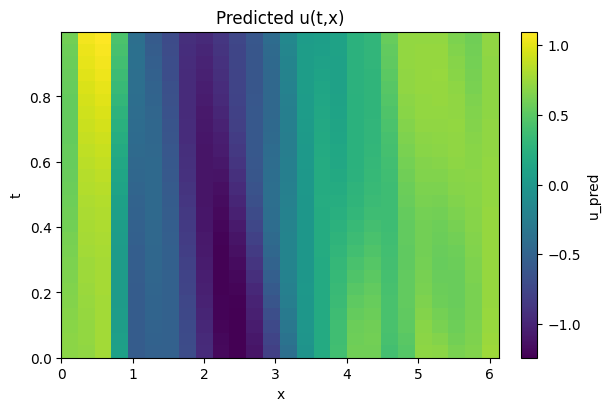

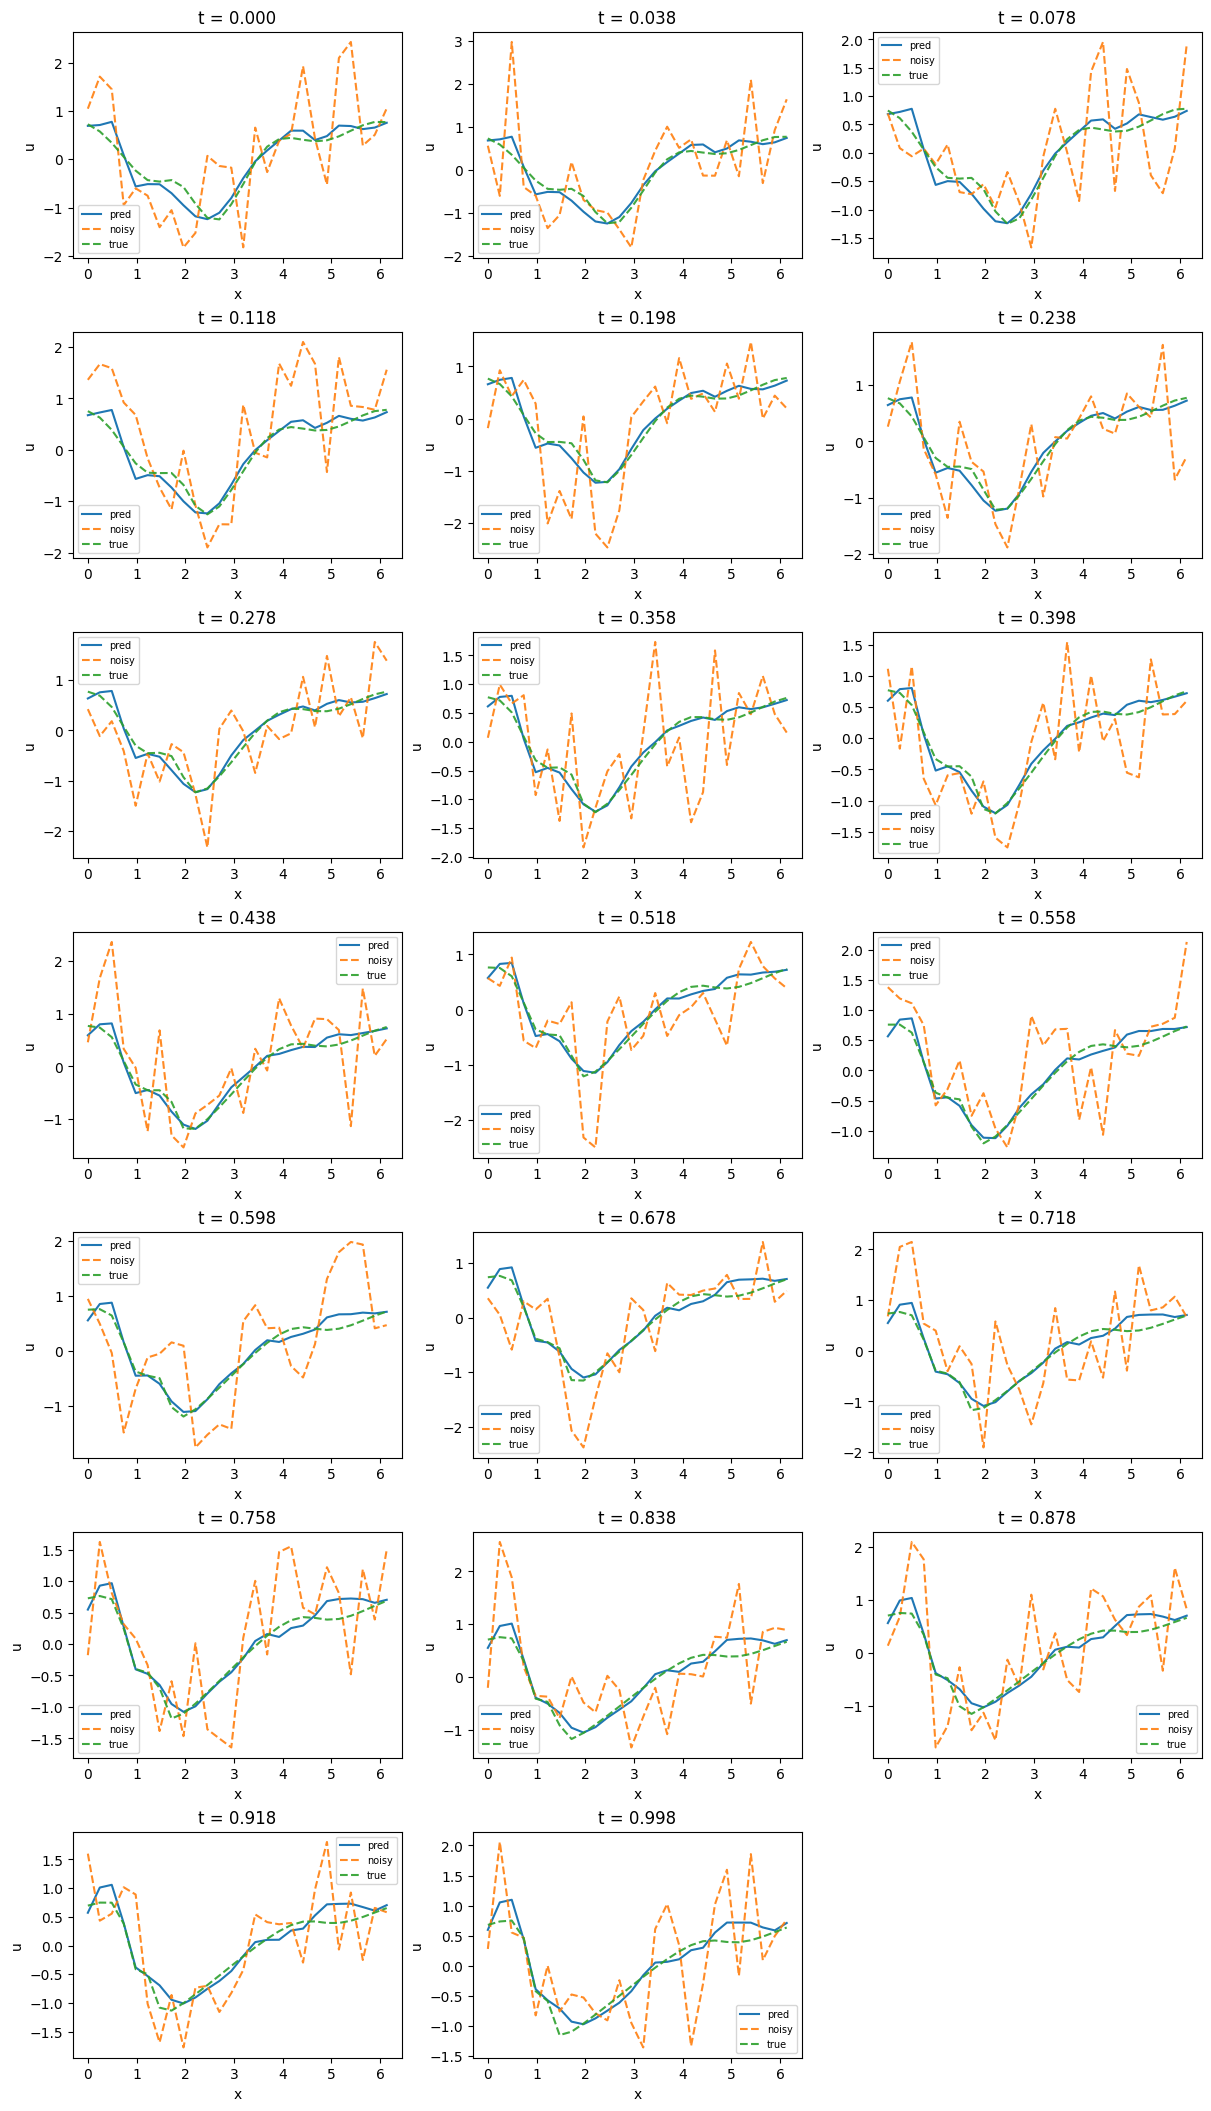

In [49]:
hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=20)[:0]